In [9]:
%run -i '../../DL Vorlesung/Preamble.py'
import numpy as np
import pandas as pd
import json
from pathlib import Path
import sys
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import networkx as nx
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util

In [2]:
df = util.load_data('../../data_csv/Data_iaaf_scores_neu.csv')
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
226678,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545
226679,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543
226680,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542
226681,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541


In [26]:
df_pivot = df.pivot_table(index='name', columns='disziplin', values='iaaf_score')
# df_filled = df_pivot.fillna(df_pivot.mean())

df_filled = df_pivot

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filled)

X_scaled

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(34985, 34))

In [31]:
corr_matrix = np.corrcoef(X_scaled.T)
corr_df = df_filled.corr(method='pearson', min_periods=5)

corr_df

disziplin,10 000 m,10 000 m Gehen,10 km,100 km,100 m,100 m Huerden,1000 m,110 m Huerden,1500 m,1500 m Hindernis,...,Halbmarathon,Hammerwurf,Hochsprung,Kugelstoss,Marathon,Siebenkampf,Speerwurf,Stabhochsprung,Weitsprung,Zehnkampf
disziplin,,,,,,,,,,,,,,,,,,,,,
10 000 m,1.000000,NaN,0.787676,0.344505,NaN,NaN,0.254783,NaN,0.604731,0.487571,...,0.805714,-0.716391,NaN,0.512600,0.698252,-0.067549,0.121198,NaN,NaN,NaN
10 000 m Gehen,NaN,1.000000,0.250556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10 km,0.787676,0.250556,1.000000,0.448895,0.399011,NaN,0.377371,NaN,0.680609,0.536216,...,0.855868,0.360539,0.415691,-0.085543,0.585253,0.271151,0.152801,-0.670363,0.290156,0.232499
100 km,0.344505,NaN,0.448895,1.000000,NaN,NaN,NaN,NaN,-0.571943,NaN,...,0.121212,NaN,NaN,NaN,0.455002,NaN,NaN,NaN,NaN,NaN
100 m,NaN,NaN,0.399011,NaN,1.000000,0.251875,0.140255,0.216361,0.310644,-0.487808,...,NaN,-0.249266,0.655553,0.005025,NaN,0.224787,0.402198,0.437498,0.709515,0.433396
100 m Huerden,NaN,NaN,NaN,NaN,0.251875,1.000000,NaN,NaN,0.046634,NaN,...,-0.011946,-0.050365,0.188501,0.308202,NaN,0.052944,0.247571,-0.116783,0.175138,NaN
1000 m,0.254783,NaN,0.377371,NaN,0.140255,NaN,1.000000,0.923723,0.608277,-0.180611,...,0.185902,NaN,0.357467,NaN,-0.336629,NaN,-0.044243,-0.007736,0.251319,-0.047563
110 m Huerden,NaN,NaN,NaN,NaN,0.216361,NaN,0.923723,1.000000,NaN,NaN,...,NaN,-0.105295,-0.037195,0.264621,NaN,NaN,0.021950,0.085235,0.007829,0.457092
1500 m,0.604731,NaN,0.680609,-0.571943,0.310644,0.046634,0.608277,NaN,1.000000,0.469534,...,0.487799,0.625363,0.903250,NaN,0.306111,0.228638,-0.159435,-0.142041,0.342300,NaN


In [34]:
G = nx.Graph()

for disziplin in df_filled.columns:
    G.add_node(disziplin)

threshold = 0.3

for i, d1 in enumerate(df_filled.columns):
    for j, d2 in enumerate(df_filled.columns):
        if i < j:
            weight = corr_df.loc[d1, d2]
            if abs(weight) > threshold:
                G.add_edge(d1, d2, weight=weight)

/opt/homebrew/Caskroom/miniforge/base/envs/datalit/lib/python3.14/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/datalit/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


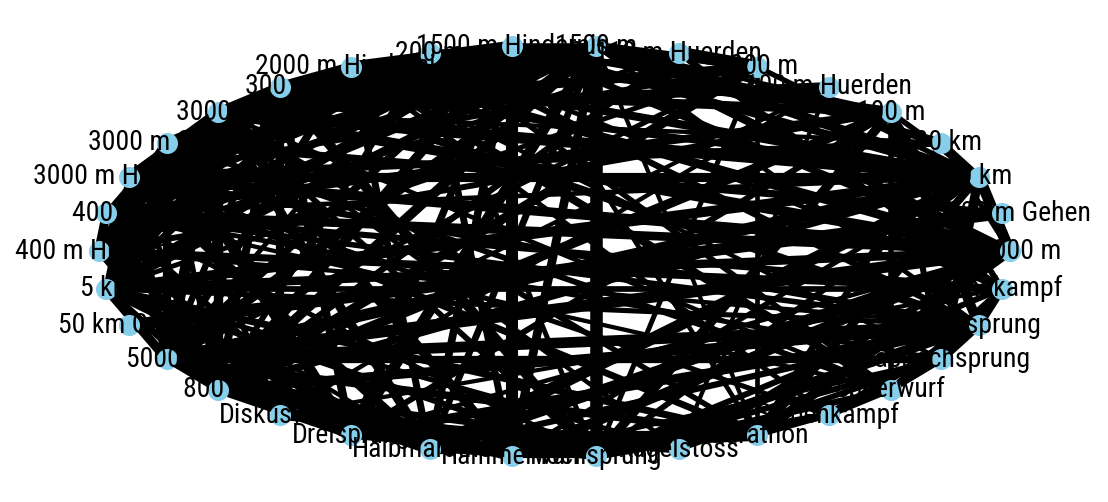

In [39]:
pos = nx.circular_layout(G)
edges = G.edges(data=True)
weights = [d['weight']*5 for (u, v, d) in edges]

nx.draw(G, pos, with_labels=True, width=weights, node_color='skyblue', node_size=50, font_size=10)